# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студенты гр. 2384 Поглазов Никита Васильевич и Вовченко София Евгеньевна. Вариант 14.

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.


## Основные теоретические положения

**Генеральная совокупность** — совокупность всех объектов, обладающих изучаемым признаком.

**Выборка** — часть генеральной совокупности, отобранная по определённому правилу для анализа.

Ранжированный ряд - упорядоченные по возрастанию значения признака:
$$
x_{(1)} \le x_{(2)} \le \dots \le x_{(n)}.
$$

Вариационный ряд - набор различных значений признака $x_j$ и соответствующих им частот $m_j$.

- Относительная частота:
$$
\tilde m_j = \frac{m_j}{n}.
$$

- Накопленная частота:
$$
m^{\text{нак}}_j = \sum_{t \le j} m_t.
$$

- Накопленная относительная частота:
$$
\tilde m^{\text{нак}}_j = \sum_{t \le j} \tilde m_t.
$$


Интервальный ряд получают разбиением диапазона значений
$[x_{\min}, x_{\max}]$ на $k$ интервалов с последующим подсчётом частот в каждом интервале.

Число интервалов (по формуле Стерджесса):
$$
k = \left\lceil 1 + 3.322 \log_{10}(n) \right\rceil.
$$

Ширина интервала:
$$
h = \frac{x_{\max} - x_{\min}}{k}.
$$

Середина интервала:
$$
\tilde x_i = \frac{x_i + x_{i+1}}{2}.
$$


- **Полигон частот** строится по точкам $(\tilde x_i, m_i)$ или $(\tilde x_i, \tilde m_i)$.
- **Гистограмма** изображает интервалы в виде столбцов, высота которых равна частоте или относительной частоте.


Эмпирическая функция распределения определяется формулой:
$$
F_n(x)=\frac{1}{n}\sum_{i=1}^n I\{x_i \le x\}.
$$

Это ступенчатая неубывающая функция, принимающая значения от 0 до 1 и показывающая долю наблюдений, не превышающих значение $x$.

## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

1. Выбрать программное обеспечение или язык программирования для выполнения практических работ и обосновать его выбор.


Выбран язык Python, т.к. это основной язык для анализа данных, предоставляющий библиотеки для обработки и анализа одномерных и двумерных данных c помощью numpy и pandas, а также их визуализации с помощью matplotlib и seaborn.

2. Выбрать двумерную генеральную совокупность, предварительно согласовав её с преподавателем. Указать, откуда была взята генеральная совокупность и предоставить ссылку. 


В качестве генеральной совокупности был взят датасет Iris https://www.kaggle.com/datasets/uciml/iris

3. Из генеральной совокупности сформировать выборку заданного объёма в соответствии с полученным от преподавателя номером. Указать, каким образом была сформирована выборка.

Была сформирована выборка размером 107 образцов. Было взято 108 образцов из генеральной совокупности (по 36 из каждого класса) и удален 1 образец первого класса. Также из исходных 4 признаков были оставлены только 2 - SepalLength и SepalWidth. 

In [2]:
from math import ceil, log10
from IPython.display import display_markdown

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../samples.csv")
df.head()

,SepalLengthCm,SepalWidthCm
0,4.9,3.0
1,4.7,3.2
2,4.6,3.1
3,5.0,3.6
4,5.4,3.9


4. Последовательно преобразовать выборку в ранжированный, вариационный и интервальный ряды. Интервальный ряд представить в виде табл. 1. Результаты содержательно проинтерпретировать.


In [5]:
length_ranged = df.SepalLengthCm.sort_values(ignore_index=True)
length_ranged

0      4.3
1      4.4
2      4.6
3      4.6
4      4.6
      ... 
102    7.7
103    7.7
104    7.7
105    7.7
106    7.9
Name: SepalLengthCm, Length: 107, dtype: float64

In [6]:
length_variational = length_ranged.value_counts().sort_index()
length_variational

SepalLengthCm
4.3    1
4.4    1
4.6    3
4.7    2
4.8    4
4.9    5
5.0    6
5.1    4
5.2    4
5.4    6
5.5    4
5.6    4
5.7    5
5.8    5
5.9    2
6.0    5
6.1    5
6.2    2
6.3    6
6.4    6
6.5    4
6.6    2
6.7    4
6.8    2
6.9    2
7.0    1
7.1    1
7.2    3
7.3    1
7.4    1
7.6    1
7.7    4
7.9    1
Name: count, dtype: int64

In [7]:
intervals_number = ceil(1 + 3.322 * log10(len(df)))
length_min, length_max = length_ranged[[0, len(df) - 1]]
interval_size = (length_max - length_min) / intervals_number

bins = length_min + np.array([i * interval_size for i in range(intervals_number + 1)])
bins[-1] += 1e-10  # чтобы алгоритм включил максиммальное число в последний интервал
bins

array([4.3 , 4.75, 5.2 , 5.65, 6.1 , 6.55, 7.  , 7.45, 7.9 ])

In [8]:
cuts = pd.cut(length_ranged, bins=bins, right=False)
interval_counts = cuts.value_counts().sort_index().to_numpy()

In [9]:
interval_centers = (bins[:-1] + bins[1:]) / 2

length_intervals = pd.DataFrame(
    {
        "$i$": np.arange(1, intervals_number + 1),
        "$[x_i; x_{i+1})$": [
            f"[{bins[i]:.2f}; {bins[i + 1]:.2f})" for i in range(intervals_number)
        ],
        r"$\tilde{x}_i$": np.round(interval_centers, 2),
        "$m_i$": interval_counts,
    }
)
length_intervals[r"$\tilde{m}_i$"] = interval_counts / len(df)
length_intervals[r"$m_i^{нак}$"] = interval_counts.cumsum()
length_intervals[r"$\tilde{m}_i^{нак}$"] = length_intervals[r"$\tilde{m}_i$"].cumsum()

sum_row = pd.DataFrame(
    [
        {
            "$i$": r"$\Sigma$",
            "$[x_i; x_{i+1})$": "",
            r"$\tilde{x}_i$": "",
            "$m_i$": interval_counts.sum(),
            r"$\tilde{m}_i$": length_intervals[r"$\tilde{m}_i$"].sum(),
            r"$m_i^{нак}$": "-",
            r"$\tilde{m}_i^{нак}$": "-",
        }
    ]
)

length_intervals = pd.concat([length_intervals, sum_row])

display_markdown(length_intervals.to_markdown(), raw=True)

|    | $i$      | $[x_i; x_{i+1})$   | $\tilde{x}_i$   |   $m_i$ |   $\tilde{m}_i$ | $m_i^{нак}$   | $\tilde{m}_i^{нак}$   |
|---:|:---------|:-------------------|:----------------|--------:|----------------:|:--------------|:----------------------|
|  0 | 1        | [4.30; 4.75)       | 4.53            |       7 |       0.0654206 | 7             | 0.06542056074766354   |
|  1 | 2        | [4.75; 5.20)       | 4.97            |      19 |       0.17757   | 26            | 0.24299065420560745   |
|  2 | 3        | [5.20; 5.65)       | 5.43            |      18 |       0.168224  | 44            | 0.41121495327102797   |
|  3 | 4        | [5.65; 6.10)       | 5.88            |      17 |       0.158879  | 61            | 0.5700934579439252    |
|  4 | 5        | [6.10; 6.55)       | 6.32            |      23 |       0.214953  | 84            | 0.7850467289719626    |
|  5 | 6        | [6.55; 7.00)       | 6.78            |      10 |       0.0934579 | 94            | 0.8785046728971962    |
|  6 | 7        | [7.00; 7.45)       | 7.22            |       7 |       0.0654206 | 101           | 0.9439252336448598    |
|  7 | 8        | [7.45; 7.90)       | 7.68            |       6 |       0.0560748 | 107           | 1.0                   |
|  0 | $\Sigma$ |                    |                 |     107 |       1         | -             | -                     |

Таким образом, выборка разделилась на 8 интервалов, самый популярный интервал - 5 (21% выборки).

5. Для абсолютных частот построить полигон, гистограмму и график эмпирической функции распределения.  


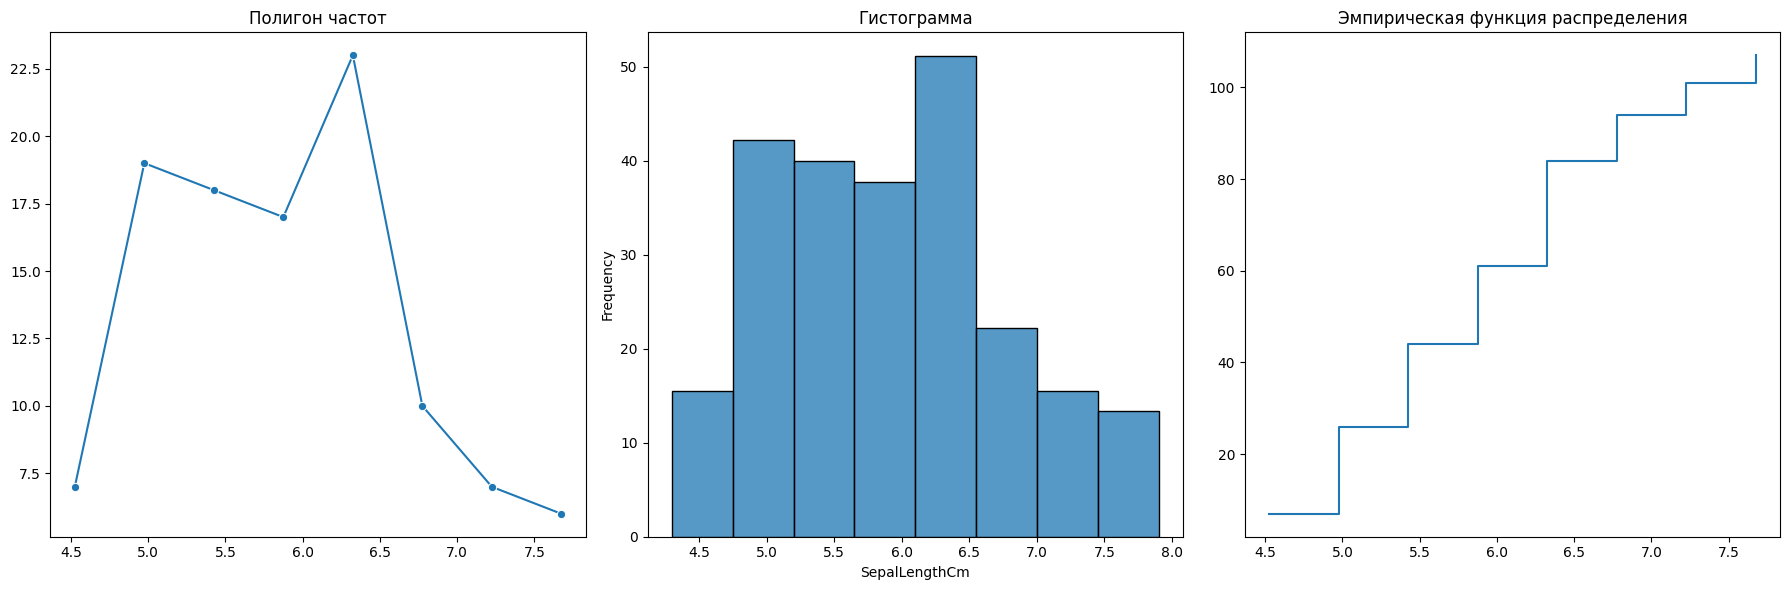

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.lineplot(y=interval_counts, x=interval_centers, marker="o", ax=axes[0])
axes[0].set_title("Полигон частот")

sns.histplot(length_ranged, bins=bins, stat="frequency", ax=axes[1])
axes[1].set_title("Гистограмма")

sns.lineplot(y=(interval_counts).cumsum(), x=interval_centers, drawstyle="steps-post", ax=axes[2])
axes[2].set_title("Эмпирическая функция распределения")

plt.tight_layout()
plt.show()

6. Повторить п. 5 для относительных частот. Сравнить и сделать выводы.


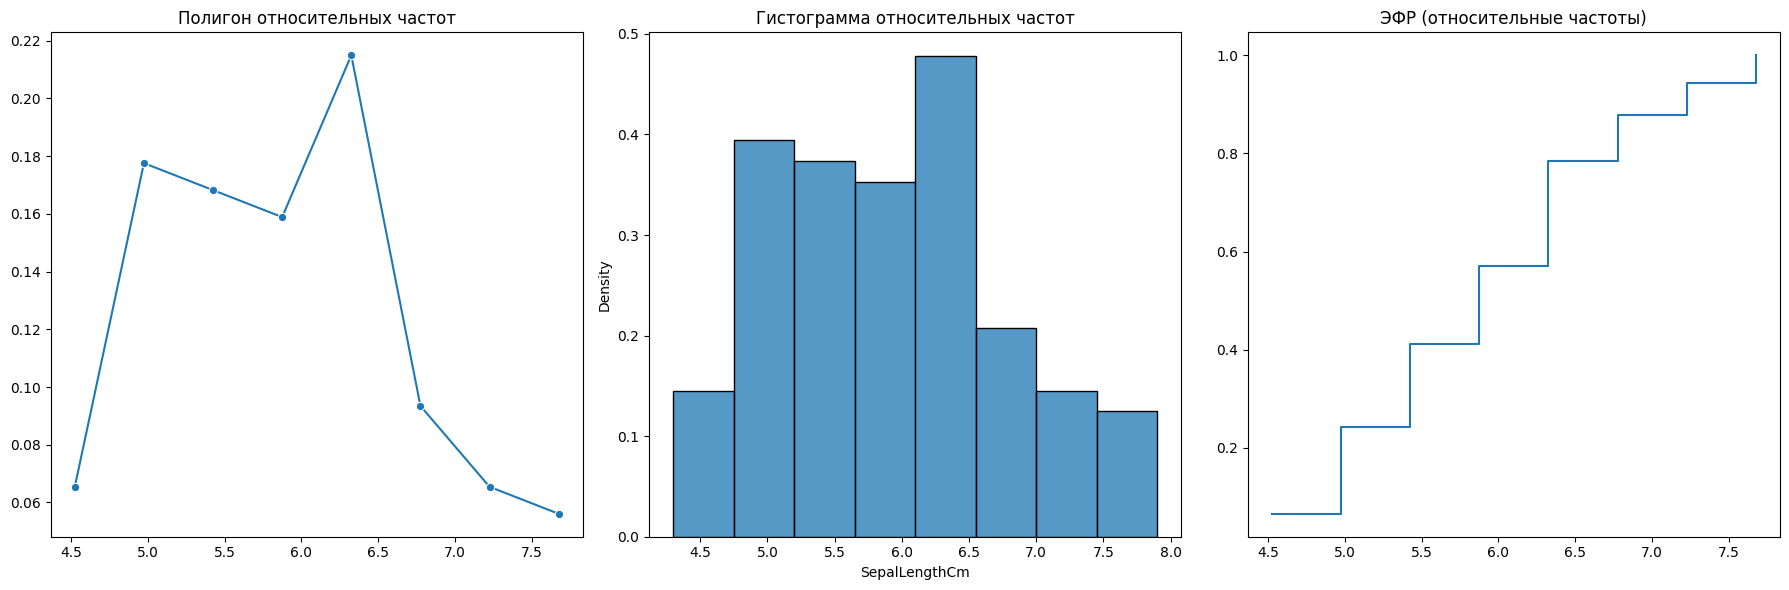

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.lineplot(y=interval_counts / len(df), x=interval_centers, marker="o", ax=axes[0])
axes[0].set_title("Полигон относительных частот")

sns.histplot(length_ranged, bins=bins, stat="density", ax=axes[1])
axes[1].set_title("Гистограмма относительных частот")

sns.lineplot(y=(interval_counts / len(df)).cumsum(), x=interval_centers, drawstyle="steps-post", ax=axes[2])
axes[2].set_title("ЭФР (относительные частоты)")

plt.tight_layout()
plt.show()

## Выводы

Данные из файла с датасетом считаны и проверены. Признак SepalLengthCm использовался для построения ранжированных, вариационных и интервальных рядов. Далее для интервального ряда были построены полигон, гистограмма и эмпирическая функция распределения для абсолютных и относительных частот. Отличие графика абсолютных частот от относительных заключается в шкале по оси Y: в первом случае она указывает количество, во втором - процент от общего числа; форма графиков не отличается.
